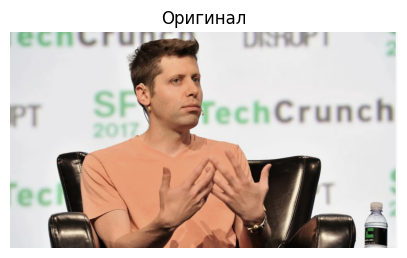

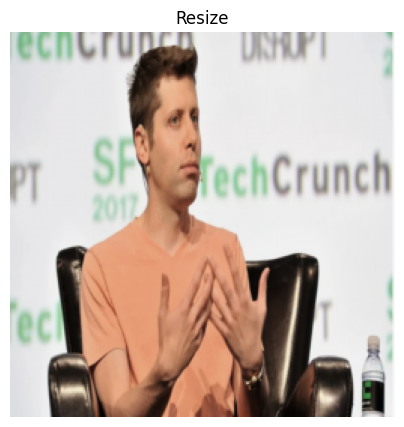

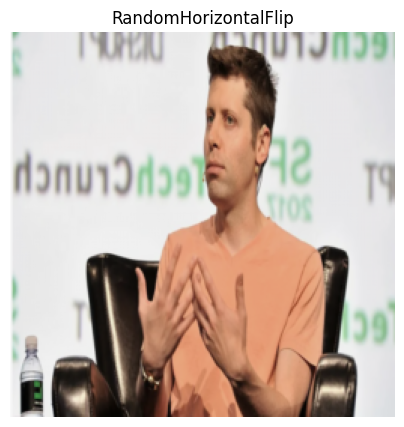

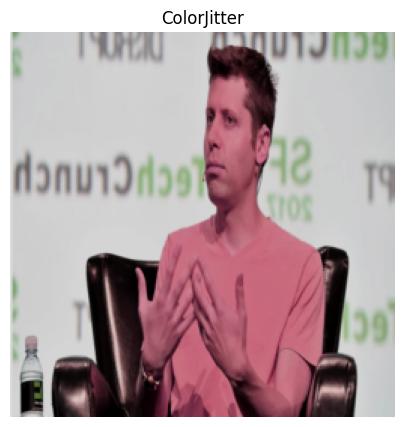

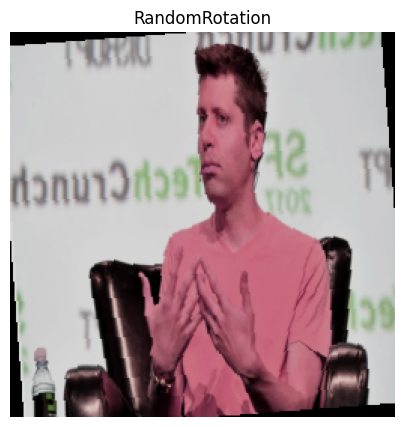

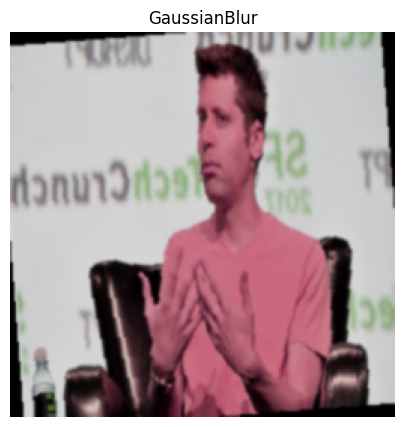

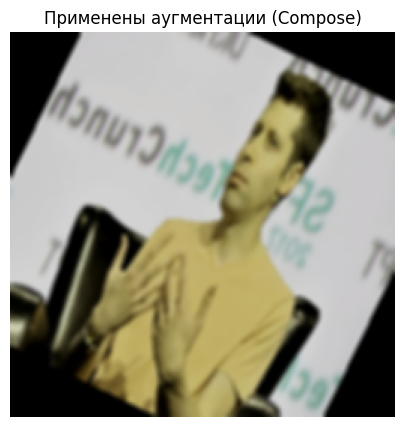

In [4]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.io.image import ImageReadMode


image_path = "/content/drive/MyDrive/Screenshot 2025-06-08 at 17.04.36.png"
image = read_image(image_path, mode=ImageReadMode.RGB).float() / 255.0

def show_image(image, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(image.permute(1, 2, 0))
    plt.title(title)
    plt.axis("off")
    plt.show()

show_image(image, "Оригинал")

augmentations = [
    ("Resize", transforms.Resize((256, 256))),
    ("RandomHorizontalFlip", transforms.RandomHorizontalFlip(p=1)),
    ("ColorJitter", transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)),
    ("RandomRotation", transforms.RandomRotation(degrees=30)),
    ("GaussianBlur", transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)))
]

# Применение аугментаций поочерёдно
transformed_image = image.clone()
for name, transform in augmentations:
    transformed_image = transform(transformed_image)
    show_image(transformed_image, name)

# Применение всех аугментаций через Compose (для полного пайплайна)
augmentation_pipeline = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=1),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=30),
    transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0))
])

# Применение через Compose
composed_image = augmentation_pipeline(image)
show_image(composed_image, "Применены аугментации (Compose)")